# Set env

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import time
import os
import seaborn as sns
import psutil
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix,save_npz
from tqdm import tqdm
from itertools import combinations
from sklearn.metrics import mean_squared_error
sc.settings.verbosity = 3
sc.set_figure_params(scanpy=True, fontsize=18)

# Compare test data from ALRA Package

In [19]:
r_data_norm=pd.read_csv('/storage/Implem/pyALRA_package/pyALRA/data/data_test_normed_R.csv',sep=' ')
r_data_norm

,AL627309.1,RP11-206L10.2,LINC00115,NOC2L,KLHL17,HES4,ISG15,C1orf159,TTLL10,TNFRSF18,...,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB,AL592183.1,AC011841.1,PNRC2,SRSF10.1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,2.499236,0.000000,0.0,2.134023,0.0,0.0,0.0,1.552739
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,1.696049,1.696049,0.0,3.470926,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,1.873284,0.0,0.0,0.000000,...,0.000000,0.000000,3.351594,1.873284,0.0,3.528061,0.0,0.0,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,2.323182,0.000000,2.966108,2.966108,0.0,3.633166,0.0,0.0,0.0,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,2.520524,1.904724,0.0,3.564034,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16422,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,1.948314,0.000000,1.948314,2.567538,0.0,2.947096,0.0,0.0,0.0,0.000000
16423,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.841349,...,3.101000,0.000000,2.828208,2.451874,0.0,2.451874,0.0,0.0,0.0,0.000000
16424,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,2.614342,1.991855,2.995099,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
16425,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,2.356230,...,1.753633,0.000000,3.538895,1.753633,0.0,3.389573,0.0,0.0,0.0,0.000000


In [20]:
adata_norm=ad.AnnData(r_data_norm)
adata_norm

/home/alexandre_lanau/miniconda3/envs/sc_gex_tcr_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 16427 × 12776

In [21]:
k = choose_k(adata_norm.X)
print(k['k'])

14


In [22]:
adata_norm.layers['alra'] = alra(adata_norm.X, k['k'])['A_norm_rank_k_cor_sc']

Read matrix with 16427 cells and 12776 genes
Find the 0.001 quantile of each gene
Sweep


/home/alexandre_lanau/miniconda3/envs/sc_gex_tcr_env/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alexandre_lanau/miniconda3/envs/sc_gex_tcr_env/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/alexandre_lanau/miniconda3/envs/sc_gex_tcr_env/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/storage/Implem/pyALRA_package/pyALRA/core.py:113: RuntimeWarning: invalid value encountered in divide
  mu_1 = np.sum(A_norm_rank_k_cor, axis=0) / np.sum(A_norm_rank_k_cor != 0, axis=0)
/storage/Implem/pyALRA_package/pyALRA/core.py:114: RuntimeWarning: invalid value encountered in divide
  mu_2 = np.sum(A_norm, axis=0) / np.sum(A_norm != 0, axis=0)


Scaling all except for 244 columns
0.00% of the values became negative in the scaling process and were set to zero
The matrix went from 5.11% nonzero to 75.19% nonzero


In [23]:
r_data=pd.read_csv('/storage/Implem/pyALRA_package/pyALRA/data/data_test_processed_R.csv',sep=' ',header=None)

/tmp/ipykernel_13061/1720561812.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,2

In [24]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(adata_norm.layers['alra'],np.array(r_data.drop(index=0),dtype='float'))
print(mse)

0.057088874238712735


In [25]:
adata_norm.layers['r_alra']=r_data.drop(index=0)

In [26]:
adata_norm

AnnData object with n_obs × n_vars = 16427 × 12776
    layers: 'alra', 'r_alra'

# UMAP

In [29]:
sc.pp.pca(adata_norm)
sc.pp.neighbors(adata_norm)
sc.tl.leiden(adata_norm,resolution=0.9,key_added='leiden_res_0.9_norm')
sc.tl.umap(adata_norm)
sc.pl.umap(adata_norm, color='leiden_res_0.9_norm',return_fig=True)
plt.savefig('/storage/Implem/pyALRA_package/pyALRA/plots/umap_leiden_0.9_norm.pdf',bbox_inches='tight')

computing PCA
    with n_comps=50
    finished (0:00:19)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
running Leiden clustering
    finished: found 7 clusters and added
    'leiden_res_0.9_norm', the cluster labels (adata.obs, categorical) (0:00:07)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:08)


In [34]:
adata_norm.X=adata_norm.layers['r_alra']
sc.pp.pca(adata_norm)
sc.pp.neighbors(adata_norm)
sc.tl.leiden(adata_norm,resolution=0.9,key_added='leiden_res_0.9_ralra')
sc.tl.umap(adata_norm)
sc.pl.umap(adata_norm, color='leiden_res_0.9_ralra',return_fig=True)
plt.savefig('/storage/Implem/pyALRA_package/pyALRA/plots/umap_leiden_0.9_ralra.pdf',bbox_inches='tight')

In [36]:
adata_norm.X=adata_norm.layers['alra']
sc.pp.pca(adata_norm)
sc.pp.neighbors(adata_norm)
sc.tl.leiden(adata_norm,resolution=0.9,key_added='leiden_res_0.9_pyalra')
sc.tl.umap(adata_norm)
sc.pl.umap(adata_norm, color='leiden_res_0.9_pyalra',return_fig=True)
plt.savefig('/storage/Implem/pyALRA_package/pyALRA/plots/umap_leiden_0.9_pyalra.png',bbox_inches='tight')

# Benchmark computing efficiency

In [17]:
import math

def load_and_plot_benchmarks_combined(datasets, base_r_path, base_py_path, n_run, save_dir):
    """
    Load and plot benchmarks for combined datasets, saving each metric as a separate plot.

    Args:
        datasets (list of str): Names of the datasets.
        base_r_path (str): Base path to R benchmark results.
        base_py_path (str): Base path to Python benchmark results.
        n_run (int): Number of repetitions for each benchmark.
        save_dir (str): Directory where plots will be saved.
    """

    os.makedirs(save_dir, exist_ok=True)
    metrics = ['CPU_Hours', 'Memory_Usage_MB', 'k', 'Percent_Non_Zero']
    sns.set_theme(style="whitegrid", palette=None,font_scale=2)

    combined_df = pd.DataFrame()

    for dataset in datasets:
        csv_r_path = os.path.join(base_r_path, dataset, "alra_benchmark_results.csv")
        csv_py_path = os.path.join(base_py_path, dataset, "alra_benchmark_results.csv")
        df_r = pd.read_csv(csv_r_path)
        df_py = pd.read_csv(csv_py_path)
        df_r['Source'] = 'R'
        df_py['Source'] = 'Python'
        combined_df = pd.concat([combined_df, df_r, df_py], ignore_index=True)


    melted_df = pd.melt(
        combined_df,
        id_vars=['Source', 'Number_of_Cells', 'Run'],
        value_vars=metrics,
        var_name='Metric',
        value_name='Value'
    )

    for metric in metrics:
        plt.figure(figsize=(8, 6))

        if metric in ['CPU_Hours', 'Memory_Usage_MB']: 
            sns.lineplot(
                data=melted_df[melted_df['Metric'] == metric],
                x='Number_of_Cells',
                y='Value',
                hue='Source',
                marker='o',
                palette={'Python':'#95190C','R':'#E3B505'},
                ci='sd',
                err_style='bars'
            )
        else:  
            sns.barplot(
                data=melted_df[melted_df['Metric'] == metric],
                x='Number_of_Cells',
                y='Value',
                hue='Source',
                palette={'Python':'#95190C','R':'#E3B505'},
                ci='sd'  
            )

        plt.title(metric)
        plt.xlabel('Number of Cells')
        plt.ylabel(metric)
        plt.legend(title='Source')
        plt.tight_layout()

        png_path = os.path.join(save_dir, f"combined_{metric}_plot.png")
        pdf_path = os.path.join(save_dir, f"combined_{metric}_plot.pdf")
        plt.savefig(png_path, format='png')
        plt.savefig(pdf_path, format='pdf')
        plt.close()
    
datasets = ["E-MTAB-8142", "E-MTAB-7407", "E-GEOD-139324"]
base_r_path = "/storage/Implem/pyALRA_package/pyALRA/alra_benchmark_results/R"
base_py_path = "/storage/Implem/pyALRA_package/pyALRA/alra_benchmark_results/python"
save_dir = "/storage/Implem/pyALRA_package/pyALRA/plots"
n_run = 5

load_and_plot_benchmarks_combined(datasets, base_r_path, base_py_path, n_run, save_dir)

/tmp/ipykernel_13061/3927408647.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(
/tmp/ipykernel_13061/3927408647.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(
/tmp/ipykernel_13061/3927408647.py:54: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/tmp/ipykernel_13061/3927408647.py:54: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/tmp/ipykernel_13061/3927408647.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(
/tmp/ipykernel_13061/3927408647.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(
/tmp/ipykernel_13061/3927408647.py:54: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for 

In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
from itertools import combinations

def load_matrices_by_size(python_dir, r_dir):
    """Load prediction matrices and group them by dataset size based on the matrix shape."""
    python_matrices_by_size = {}
    r_matrices_by_size = {}

    # Load Python matrices
    for file in tqdm(sorted(os.listdir(python_dir))):
        if file.endswith(".h5ad"):
            adata = ad.read_h5ad(os.path.join(python_dir, file))
            matrix = adata.layers['alra'].toarray() if hasattr(adata.layers['alra'], "toarray") else adata.layers['alra']
            size = matrix.shape[0]  # Use the number of rows as the size
            python_matrices_by_size.setdefault(size, []).append(matrix)

    # Load R matrices
    for file in tqdm(sorted(os.listdir(r_dir))):
        if file.endswith(".csv"):
            matrix = pd.read_csv(os.path.join(r_dir, file), index_col=False).values
            size = matrix.shape[0]  # Use the number of rows as the size
            r_matrices_by_size.setdefault(size, []).append(matrix)

    return python_matrices_by_size, r_matrices_by_size

def compute_mse(matrix1, matrix2):
    """Compute Mean Squared Error (MSE) between two matrices."""
    return mean_squared_error(matrix1, matrix2)

def analyze_and_plot_mse_by_size(dataset_name, python_dir, r_dir, output_dir):
    """Load matrices, compute MSEs, and plot results by dataset size."""
    dataset_output_dir = os.path.join(output_dir, dataset_name)
    os.makedirs(dataset_output_dir, exist_ok=True)

    # Load prediction matrices grouped by size
    python_matrices_by_size, r_matrices_by_size = load_matrices_by_size(python_dir, r_dir)

    for size in tqdm(sorted(python_matrices_by_size.keys())):
        # Matrices for the current size
        python_matrices = python_matrices_by_size[size]
        r_matrices = r_matrices_by_size.get(size, [])

        # Compute pairwise MSEs
        mse_within_py = [
            compute_mse(python_matrices[i], python_matrices[j])
            for i, j in combinations(range(len(python_matrices)), 2)
        ]
        mse_within_r = [
            compute_mse(r_matrices[i], r_matrices[j])
            for i, j in combinations(range(len(r_matrices)), 2)
        ]
        mse_between_r_py = [
            compute_mse(r_matrices[i], python_matrices[j])
            for i in range(len(r_matrices))
            for j in range(len(python_matrices))
        ]

        # Combine data for the current size
        mse_data = [
            {'Category': 'Within Python', 'MSE': mse} for mse in mse_within_py
        ] + [
            {'Category': 'Within R', 'MSE': mse} for mse in mse_within_r
        ] + [
            {'Category': 'Between R and Python', 'MSE': mse} for mse in mse_between_r_py
        ]

        # Heatmap for the current size
        heatmap_png_file = os.path.join(dataset_output_dir, f'heatmap_{size}_cells.png')
        heatmap_pdf_file = os.path.join(dataset_output_dir, f'heatmap_{size}_cells.pdf')
        plot_heatmaps(size, python_matrices, r_matrices, heatmap_png_file, heatmap_pdf_file)

        # Bar plot for the current size
        barplot_png_file = os.path.join(dataset_output_dir, f'barplot_{size}_cells.png')
        barplot_pdf_file = os.path.join(dataset_output_dir, f'barplot_{size}_cells.pdf')
        plot_mse_barplot(mse_data, size, barplot_png_file, barplot_pdf_file)

def plot_heatmaps(size, python_matrices, r_matrices, save_png_path, save_pdf_path):
    """Generate heatmaps for a given dataset size and save the plot."""
    n_py = len(python_matrices)
    n_r = len(r_matrices)

    mse_matrix_py = np.zeros((n_py, n_py))
    mse_matrix_r = np.zeros((n_r, n_r))
    mse_matrix_r_py = np.zeros((n_r, n_py))

    for i, j in combinations(range(n_py), 2):
        mse_matrix_py[i, j] = mse_matrix_py[j, i] = compute_mse(python_matrices[i], python_matrices[j])

    for i, j in combinations(range(n_r), 2):
        mse_matrix_r[i, j] = mse_matrix_r[j, i] = compute_mse(r_matrices[i], r_matrices[j])

    for i in range(n_r):
        for j in range(n_py):
            mse_matrix_r_py[i, j] = compute_mse(r_matrices[i], python_matrices[j])

    # Plot heatmaps
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    sns.heatmap(mse_matrix_py, ax=axes[0], cmap='viridis', annot=True, fmt='.2f')
    axes[0].set_title(f'MSE Heatmap (Within Python) - {size} Cells')
    axes[0].set_xlabel('Run')
    axes[0].set_ylabel('Run')

    sns.heatmap(mse_matrix_r, ax=axes[1], cmap='viridis', annot=True, fmt='.2f')
    axes[1].set_title(f'MSE Heatmap (Within R) - {size} Cells')
    axes[1].set_xlabel('Run')
    axes[1].set_ylabel('Run')

    sns.heatmap(mse_matrix_r_py, ax=axes[2], cmap='viridis', annot=True, fmt='.2f')
    axes[2].set_title(f'MSE Heatmap (Between R and Python) - {size} Cells')
    axes[2].set_xlabel('Python Run')
    axes[2].set_ylabel('R Run')

    plt.tight_layout()
    plt.savefig(save_png_path)
    plt.savefig(save_pdf_path)
    plt.close()

def plot_mse_barplot(mse_data, size, save_png_path, save_pdf_path):
    """Generate a bar plot for MSE data of a specific size and save the plot."""
    mse_df = pd.DataFrame(mse_data)
    plt.figure(figsize=(12, 8))
    sns.barplot(data=mse_df, x='Category', y='MSE', ci='sd', palette='flare')
    plt.title(f'Mean MSE Across Categories - {size} Cells')
    plt.ylabel('Mean MSE')
    plt.xlabel('Category')
    plt.tight_layout()
    plt.savefig(save_png_path)
    plt.savefig(save_pdf_path)
    plt.close()

# Example usage
base_python_dir = "/storage/Implem/pyALRA_package/pyALRA/alra_benchmark_results/python"
base_r_dir = "/storage/Implem/pyALRA_package/pyALRA/alra_benchmark_results/R"
output_dir = "/storage/Implem/pyALRA_package/pyALRA/plots"

datasets = ["E-MTAB-7407", "E-GEOD-139324"]

for dataset in datasets:
    python_dir = os.path.join(base_python_dir, dataset, "bench_runs")
    r_dir = os.path.join(base_r_dir, dataset, "bench_runs")
    analyze_and_plot_mse_by_size(dataset, python_dir, r_dir, output_dir)


  0%|          | 0/3 [00:00<?, ?it/s]/tmp/ipykernel_31077/836995006.py:128: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=mse_df, x='Category', y='MSE', ci='sd', palette='flare')
/tmp/ipykernel_31077/836995006.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mse_df, x='Category', y='MSE', ci='sd', palette='flare')
 33%|███▎      | 1/3 [00:16<00:33, 16.91s/it]/tmp/ipykernel_31077/836995006.py:128: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=mse_df, x='Category', y='MSE', ci='sd', palette='flare')
/tmp/ipykernel_31077/836995006.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for 

KeyboardInterrupt: 

/tmp/ipykernel_13061/81276833.py:92: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


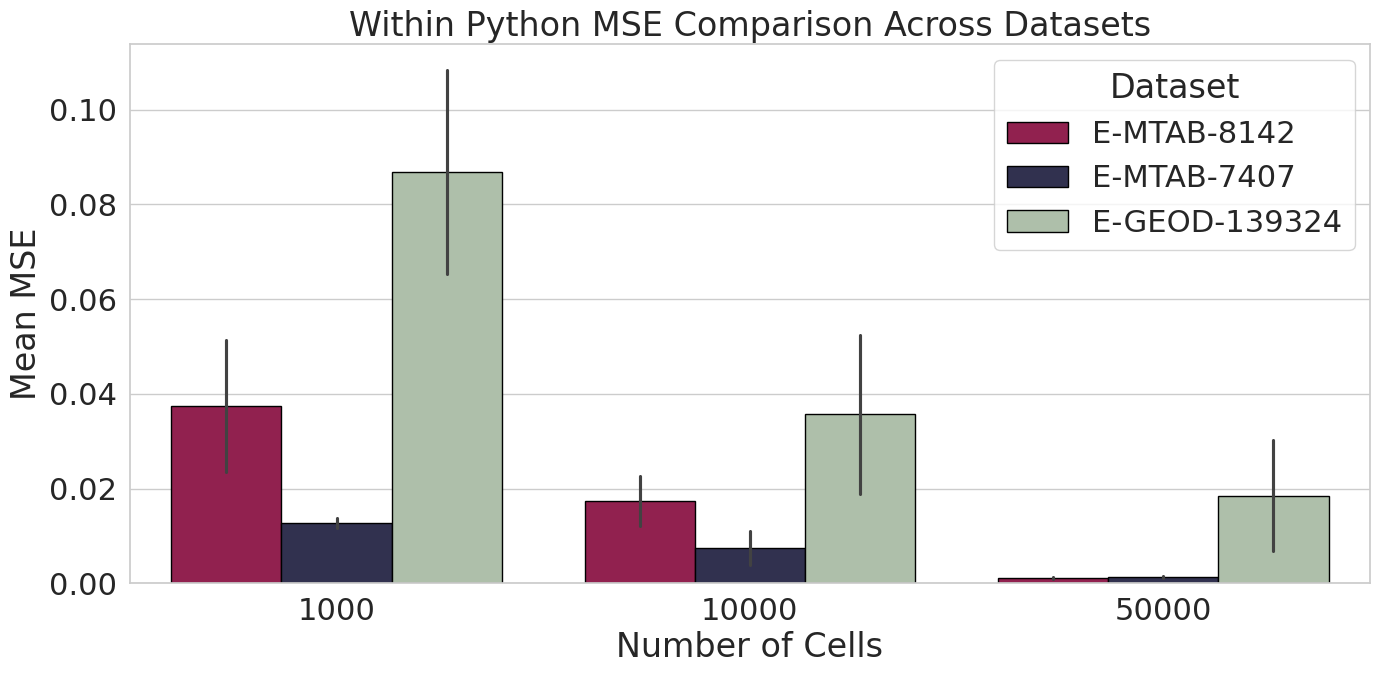

/tmp/ipykernel_13061/81276833.py:92: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


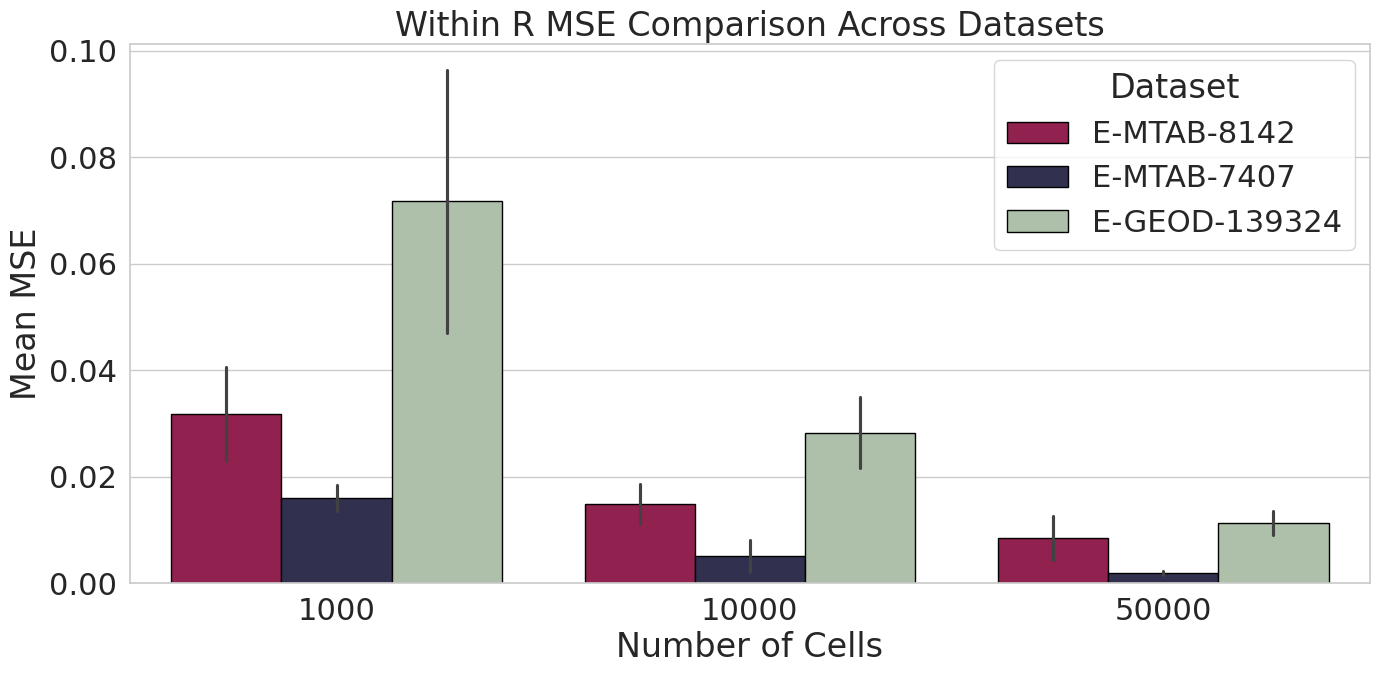

/tmp/ipykernel_13061/81276833.py:92: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


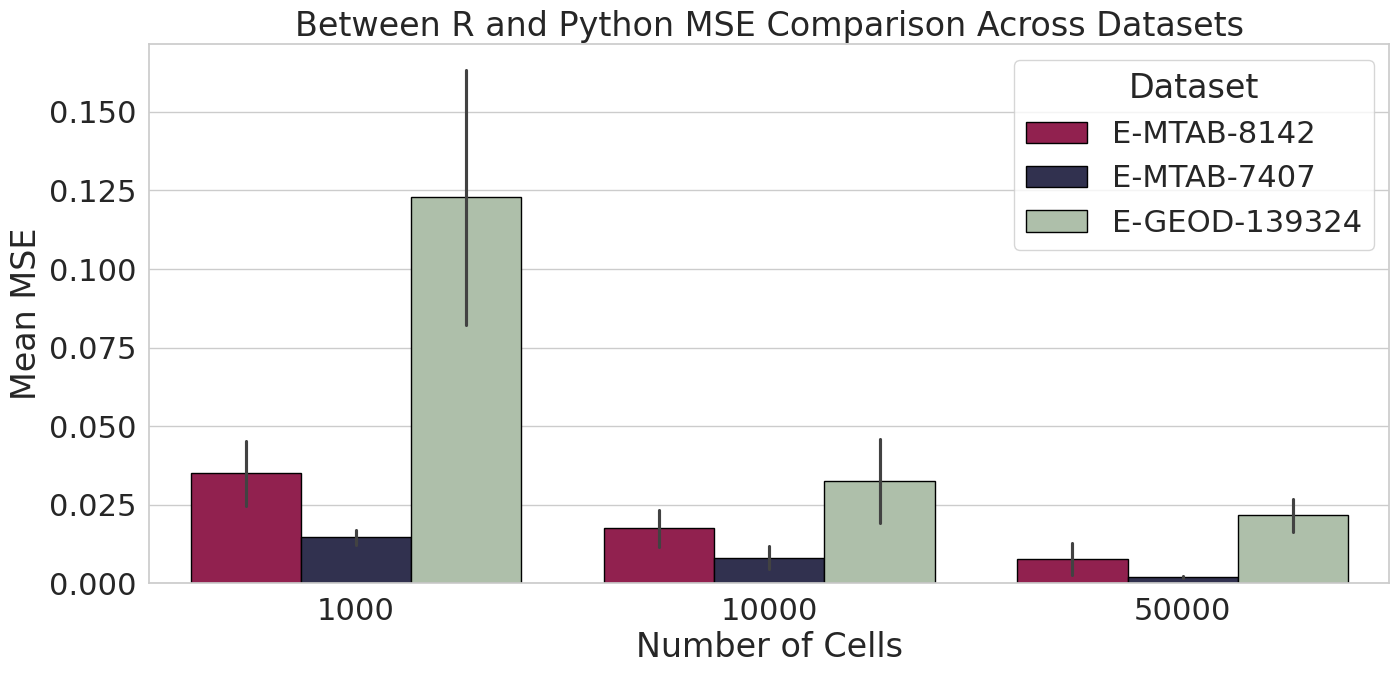

/tmp/ipykernel_13061/81276833.py:111: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


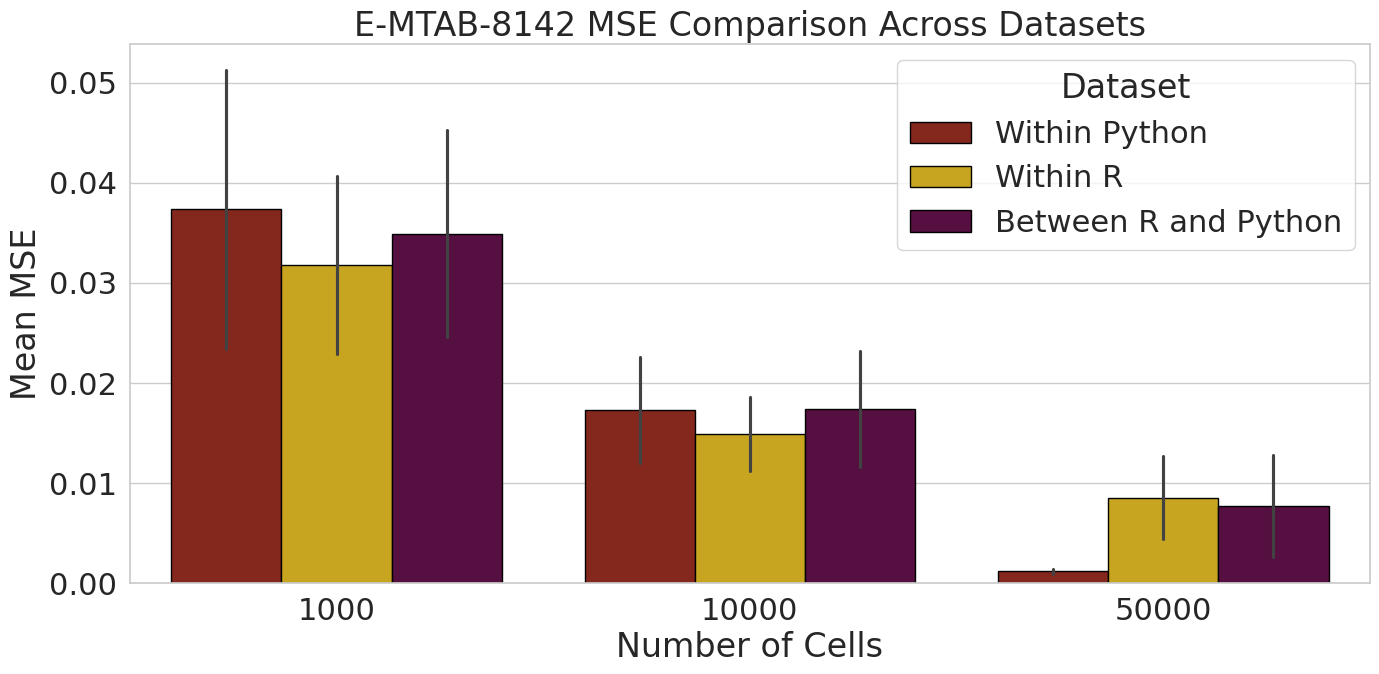

/tmp/ipykernel_13061/81276833.py:111: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


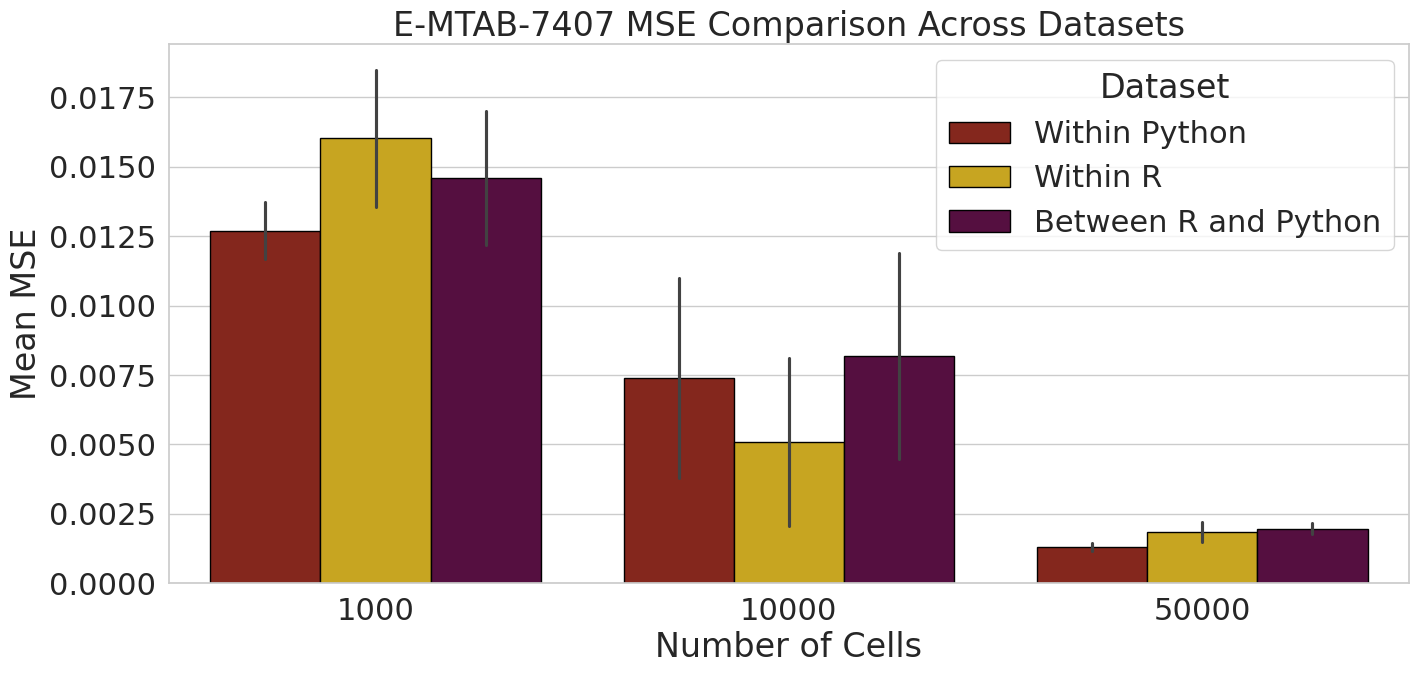

/tmp/ipykernel_13061/81276833.py:111: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


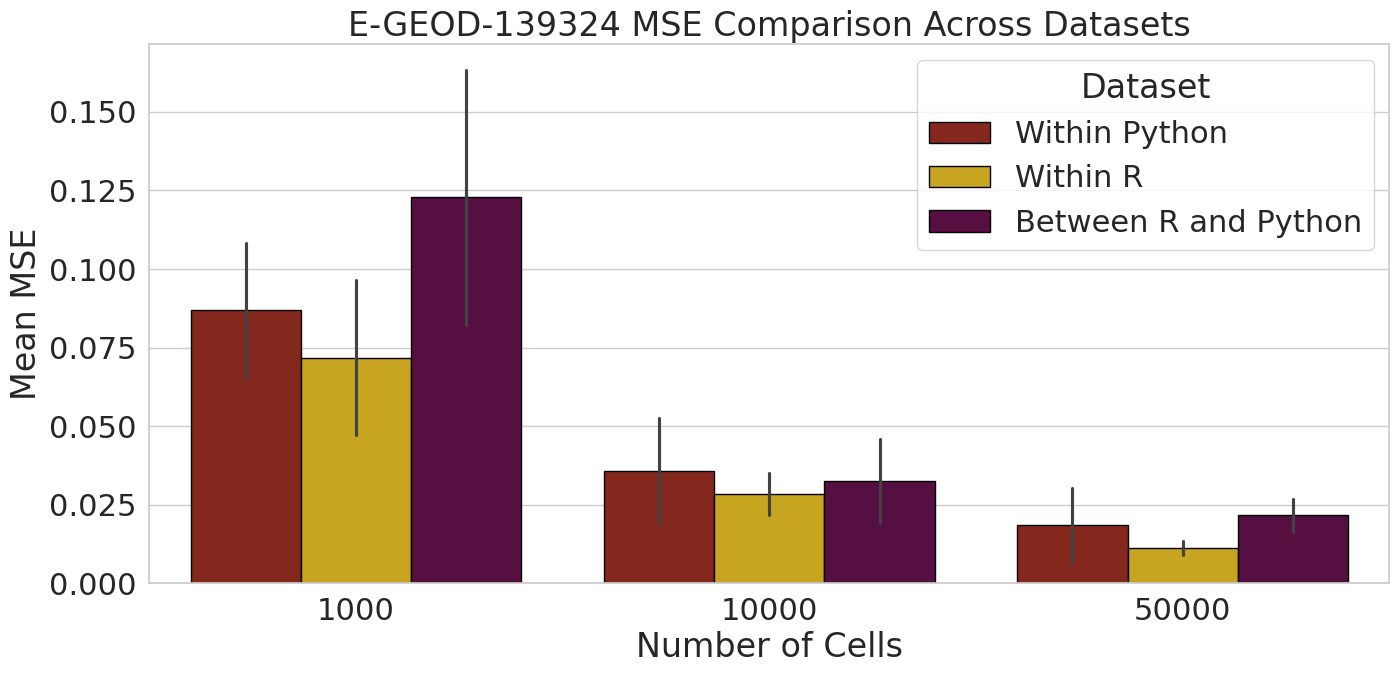

/tmp/ipykernel_13061/81276833.py:129: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


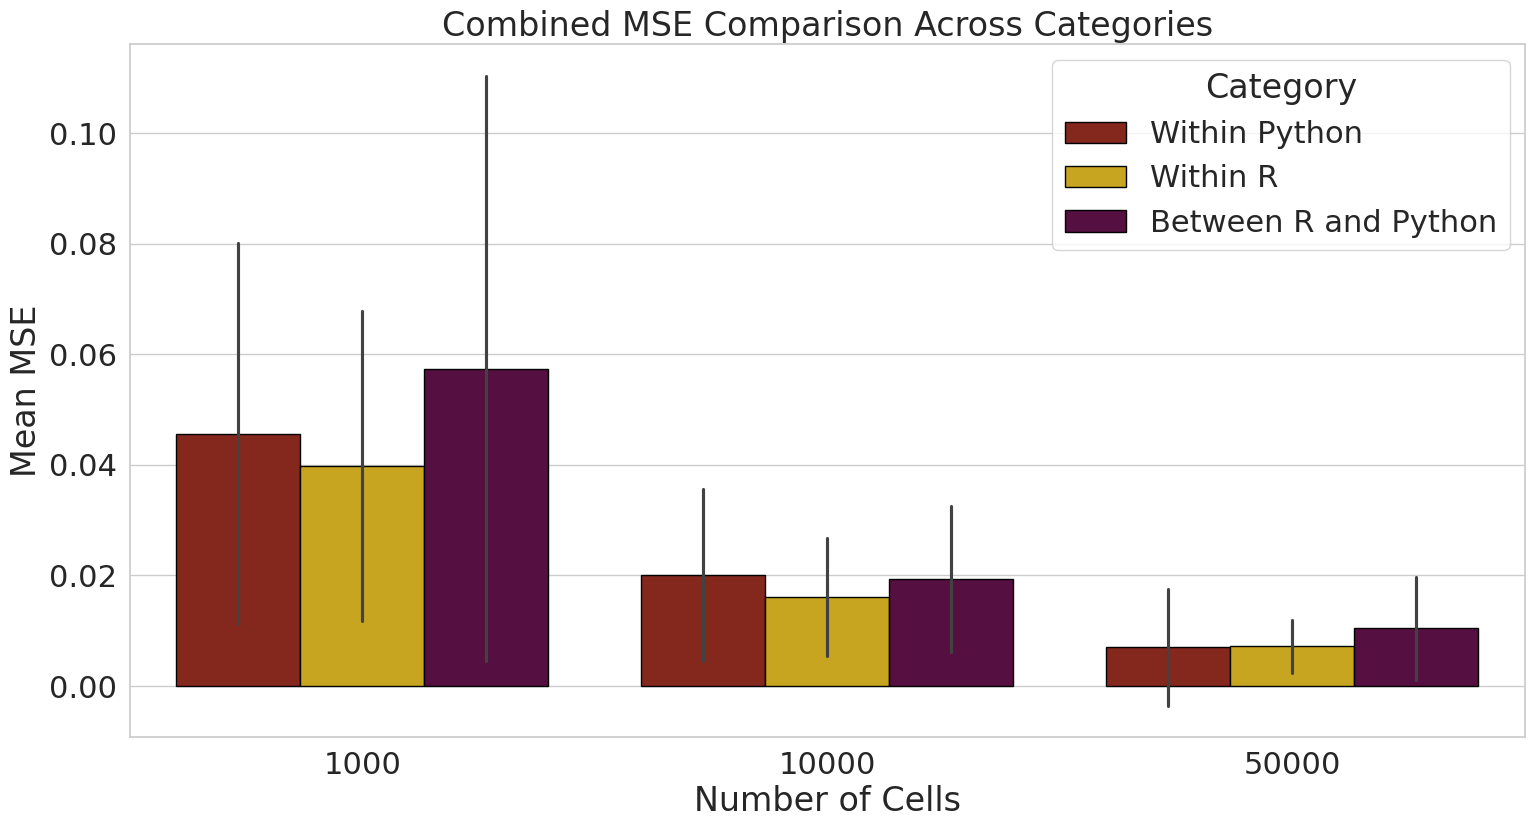

In [14]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
from itertools import combinations

def load_matrices_by_size(python_dir, r_dir):
    """Load prediction matrices and group them by dataset size based on the matrix shape."""
    python_matrices_by_size = {}
    r_matrices_by_size = {}

    # Load Python matrices
    for file in tqdm(sorted(os.listdir(python_dir))):
        if file.endswith(".h5ad"):
            adata = ad.read_h5ad(os.path.join(python_dir, file))
            matrix = adata.layers['alra'].toarray() if hasattr(adata.layers['alra'], "toarray") else adata.layers['alra']
            size = matrix.shape[0]  # Use the number of rows as the size
            python_matrices_by_size.setdefault(size, []).append(matrix)

    # Load R matrices
    for file in tqdm(sorted(os.listdir(r_dir))):
        if file.endswith(".csv"):
            matrix = pd.read_csv(os.path.join(r_dir, file), index_col=False).values
            size = matrix.shape[0]  # Use the number of rows as the size
            r_matrices_by_size.setdefault(size, []).append(matrix)

    return python_matrices_by_size, r_matrices_by_size

def compute_mse(matrix1, matrix2):
    """Compute Mean Squared Error (MSE) between two matrices."""
    return mean_squared_error(matrix1.flatten(), matrix2.flatten())

def compute_mse_for_datasets(dataset_dirs):
    """Compute MSEs for all datasets and subdatasets."""
    all_mse_results = []

    for dataset_name, (python_dir, r_dir) in dataset_dirs.items():
        print(f"Processing dataset: {dataset_name}")
        python_matrices_by_size, r_matrices_by_size = load_matrices_by_size(python_dir, r_dir)

        for size in tqdm(sorted(python_matrices_by_size.keys())):
            if size not in r_matrices_by_size:
                continue

            python_matrices = python_matrices_by_size[size]
            r_matrices = r_matrices_by_size[size]

            # Within Python
            for i, j in combinations(range(len(python_matrices)), 2):
                mse = compute_mse(python_matrices[i], python_matrices[j])
                all_mse_results.append({
                    'Dataset': dataset_name,
                    'Size': size,
                    'Category': 'Within Python',
                    'MSE': mse
                })

            # Within R
            for i, j in combinations(range(len(r_matrices)), 2):
                mse = compute_mse(r_matrices[i], r_matrices[j])
                all_mse_results.append({
                    'Dataset': dataset_name,
                    'Size': size,
                    'Category': 'Within R',
                    'MSE': mse
                })

            # Between R and Python
            for i, r_matrix in enumerate(r_matrices):
                for j, py_matrix in enumerate(python_matrices):
                    mse = compute_mse(r_matrix, py_matrix)
                    all_mse_results.append({
                        'Dataset': dataset_name,
                        'Size': size,
                        'Category': 'Between R and Python',
                        'MSE': mse
                    })

    return pd.DataFrame(all_mse_results)

def plot_mse_results(mse_df, save_dir):
    """Generate bar plots for MSE results."""
    mse_df['Size'] = mse_df['Size'].astype(str)  # Convert size to string for better plotting
    sns.set_theme(style="whitegrid", palette=None,font_scale=2)

    # Plot for each category separately by dataset
    for category in mse_df['Category'].unique():
        plt.figure(figsize=(16, 7))
        sns.barplot(
            data=mse_df[mse_df['Category'] == category],
            x='Size', y='MSE', hue='Dataset',
            ci='sd', palette={'E-MTAB-8142': '#A40E4C', 'E-MTAB-7407': '#2C2C54', 'E-GEOD-139324': '#ACC3A6'},
            edgecolor='black'
        )
        plt.title(f'{category} MSE Comparison Across Datasets')
        plt.ylabel('Mean MSE')
        plt.xlabel('Number of Cells')
        plt.legend(title='Dataset', loc='upper right')
        png_path = os.path.join(save_dir, f"{category.replace(' ', '_').lower()}_mse_plot.png")
        pdf_path = os.path.join(save_dir, f"{category.replace(' ', '_').lower()}_mse_plot.pdf")
        plt.savefig(png_path, format='png')
        plt.savefig(pdf_path, format='pdf')
        plt.show()
        
    # Plot for each category separately by dataset
    for category in mse_df['Dataset'].unique():
        plt.figure(figsize=(16, 7))
        sns.barplot(
            data=mse_df[mse_df['Dataset'] == category],
            x='Size', y='MSE', hue='Category',
            ci='sd', palette={'Within Python':'#95190C','Within R':'#E3B505','Between R and Python':'#610345'},
            edgecolor='black'
        )
        plt.title(f'{category} MSE Comparison Across Datasets')
        plt.ylabel('Mean MSE')
        plt.xlabel('Number of Cells')
        plt.legend(title='Dataset', loc='upper right')
        png_path = os.path.join(save_dir, f"{category.replace(' ', '_').lower()}_mse_plot.png")
        pdf_path = os.path.join(save_dir, f"{category.replace(' ', '_').lower()}_mse_plot.pdf")
        plt.savefig(png_path, format='png')
        plt.savefig(pdf_path, format='pdf')
        plt.show()

    # Combined plot across all categories
    plt.figure(figsize=(18, 9))
    sns.barplot(
        data=mse_df, x='Size', y='MSE', hue='Category',
        ci='sd', palette={'Within Python':'#95190C','Within R':'#E3B505','Between R and Python':'#610345'}, edgecolor='black'
    )
    plt.title('Combined MSE Comparison Across Categories')
    plt.ylabel('Mean MSE')
    plt.xlabel('Number of Cells')
    plt.legend(title='Category', loc='upper right')
    png_path = os.path.join(save_dir, "combined_mse_plot.png")
    pdf_path = os.path.join(save_dir, "combined_mse_plot.pdf")
    plt.savefig(png_path, format='png')
    plt.savefig(pdf_path, format='pdf')
    plt.show()

# Main Execution
dataset_dirs = {
    "E-MTAB-8142": (
        "/storage/Implem/pyALRA_package/pyALRA/alra_benchmark_results/python/E-MTAB-8142/bench_runs/",
        "/storage/Implem/pyALRA_package/pyALRA/alra_benchmark_results/R/E-MTAB-8142/bench_runs/"
    ),
    "E-MTAB-7407": (
        "/storage/Implem/pyALRA_package/pyALRA/alra_benchmark_results/python/E-MTAB-7407/bench_runs/",
        "/storage/Implem/pyALRA_package/pyALRA/alra_benchmark_results/R/E-MTAB-7407/bench_runs/"
    ),
    "E-GEOD-139324": (
        "/storage/Implem/pyALRA_package/pyALRA/alra_benchmark_results/python/E-GEOD-139324/bench_runs/",
        "/storage/Implem/pyALRA_package/pyALRA/alra_benchmark_results/R/E-GEOD-139324/bench_runs/"
    )
}
save_dir = "/storage/Implem/pyALRA_package/pyALRA/plots"

# # Compute MSEs and plot results
# mse_results_df = compute_mse_for_datasets(dataset_dirs)
plot_mse_results(mse_results_df, save_dir)